In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import modules.loaddata
import modules.loadroot
import importlib

# Load data and plot histogram
Change where the events file is loaded from

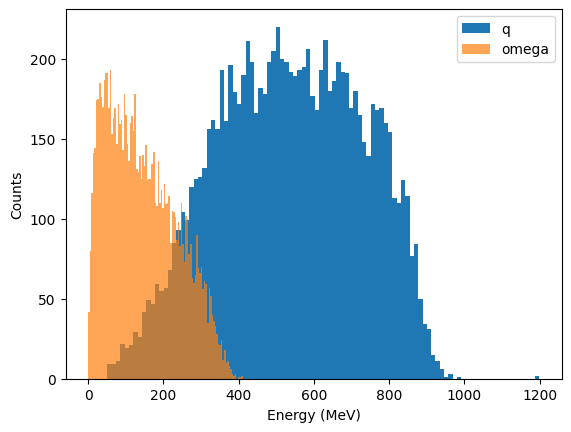

In [4]:
importlib.reload(modules.loadroot)
importlib.reload(modules.loaddata)
mom_ins, mom_outs, q_vals, omega_vals = modules.loadroot.load_events_file("../nuwro/eventsout.root")
plt.hist(q_vals, bins=100, label="q")
plt.hist(omega_vals, bins=100, alpha=0.7, label="omega")
plt.legend()
plt.xlabel("Energy (MeV)")
plt.ylabel("Counts")
None

# $q/\omega$ scatterplot

Text(0.5, 0, 'q')

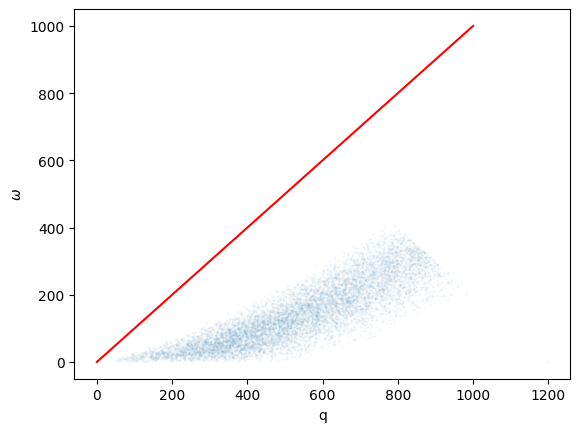

In [5]:
plt.scatter(q_vals, omega_vals, s=0.1, alpha=0.1)
plt.plot([0, 1000], [0,1000], color="red")
plt.ylabel("$\\omega$")
plt.xlabel("q")

# $q$ slice comparison to expected response

In [6]:
# Load lfg data, create interpolator
lfg_q, lfg_data = modules.loaddata.load_response_functions("./data/lfg_week4_data/", "responses_C12_CC_LFG")
funcs = modules.loaddata.build_spectral_interpolator(lfg_q, lfg_data)
t2k_bins, t2k_vals = modules.loaddata.load_t2k("data/t2k/t2kflux_2020_plus250kA_nominal_nd280.txt")


/tmp/ipykernel_2006921/544349975.py:12: RuntimeWarning: invalid value encountered in sqrt
  k_prim = np.sqrt(eps_prim**2 - m_l**2)


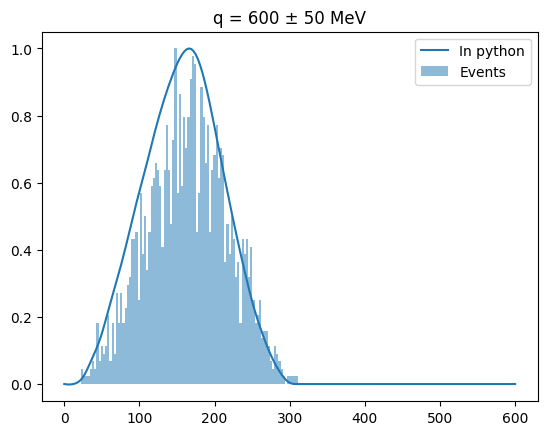

In [7]:
target_q = 600 # q for which to plot
q_delta = 50 # how wide the q slice should be

eps = 600 # Beam energy
#muon mass
m_l = 105.66

# omega = test_x
omega = np.linspace(0, 600, 200)
eps_prim = eps - omega
k = eps
k_prim = np.sqrt(eps_prim**2 - m_l**2)

Q_sq = target_q**2 - omega**2

costheta = (k**2 + k_prim**2 - target_q**2) / (2 * k * k_prim)
# costheta = np.arccos(temp)
# costheta = np.nan_to_num(costheta)


v00 = 2 * eps * eps_prim * ( 1 + k_prim/eps_prim * costheta )
vzz = omega**2 / target_q**2 * (m_l ** 2 + v00) + m_l**2 / target_q**2 * (m_l**2 + 2 * omega * (eps + eps_prim) + target_q**2)
v0z = omega / target_q * (m_l**2 + v00) + m_l**2 / target_q * (eps + eps_prim)
vxx = Q_sq + Q_sq * (m_l**2 + v00) / (2 * target_q**2) - m_l**2 / target_q**2 * (m_l**2 / 2 + omega * (eps + eps_prim))
vxy = Q_sq * (eps + eps_prim) / target_q - m_l**2 * omega / target_q
# r00 r0z rzz rxx rxy
coeffs = np.array([v00, -v0z, vzz, vxx, -vxy])



mask = np.abs(q_vals - target_q) < q_delta

counts, bins = np.histogram(omega_vals[mask], bins=100)
normcounts = counts / np.max(counts)

nrf_vals = np.array([
    funcs[0]((target_q, omega)),
    funcs[1]((target_q, omega)),
    funcs[2]((target_q, omega)),
    funcs[3]((target_q, omega)),
    funcs[4]((target_q, omega)),
])

cross_section = np.nan_to_num(k_prim / eps * np.sum(nrf_vals * coeffs, axis=0))

plt.Figure(figsize=(10,6), dpi=300)


plt.plot(omega + 34*0, cross_section / (np.max(cross_section)), label="In python")
# plt.plot(test_x + 34, test_y / np.max(test_y), label="From nuwro", linestyle="dashed")
# for cidx in range(5):
#     plt.plot(lfg_data[lfg_idx, cidx, 0], lfg_data[lfg_idx, cidx, 1] / np.max(np.abs(lfg_data[lfg_idx, cidx, 1])) * 0.5, label=f"NRF {cidx}")
plt.bar(bins[:-1], normcounts, width=np.diff(bins), alpha=0.5, label="Events")
plt.title(f"q = {target_q} ± {q_delta} MeV")
plt.legend()
# plt.xlim(0, 400)
# plt.ylim(-0.01, 0.01)

# NuWro T2K Beam profile

In [9]:
import scipy.interpolate
stepsize = 10
coordx = []
coordy = []
for i in range(len(t2k_bins)):
    xcoord = (t2k_bins[i][0] + t2k_bins[i][1]) / 2
    if xcoord > 1500:
        break
    coordx.append(xcoord)
    coordy.append(t2k_vals[i])

xpoints = np.arange(final_min, final_max, stepsize)

ypoints = scipy.interpolate.CubicSpline(coordx, coordy)(xpoints)


datax = []
datay = []
for x, y in zip(t2k_bins, t2k_vals):
    if x[0] > 1500:
        break
    datax.append((x[0]))
    datax.append((x[1]))
    datay.append(y)
    datay.append(y)

plt.figure(figsize=(20,12))
plt.plot(datax, datay / np.max(datay), label="Flux Data", color="black", drawstyle="steps-post", alpha=0.4)
plt.bar(xpoints, ypoints / np.max(ypoints), width=stepsize, label="Beam profile", color="orange")
plt.xlim(0, 1500)
plt.xlabel("Energy (MeV)")
plt.ylabel("Histogram Value (Normalized)")
plt.title("T2K Beam Profile")
plt.legend()

bins = ""
for y in ypoints:
    bins += f"{y/np.max(ypoints)} "

print(f"{np.min(xpoints)} {np.max(xpoints)} {bins}")

NameError: name 'final_min' is not defined